Download repositório com imagem

In [41]:
!rm -rf Atividades_bootcamp_BairesDev
!git clone https://github.com/AllJordanSS/Atividades_bootcamp_BairesDev.git -b At.3_Reducao_de_dimensionalidade

Cloning into 'Atividades_bootcamp_BairesDev'...
remote: Enumerating objects: 515, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 515 (delta 1), reused 7 (delta 0), pack-reused 501 (from 1)
Receiving objects: 100% (515/515), 134.68 MiB | 37.24 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [42]:
# Etapa 1: Importar bibliotecas básicas
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [43]:
imagem_path = 'Atividades_bootcamp_BairesDev/imagem'

# Listar arquivos na pasta para ver qual imagem usar
try:
    arquivos = os.listdir(imagem_path)
    # Filtrar apenas arquivos de imagem (extensões comuns)
    imagem_arquivo = None
    for arquivo in arquivos:
        if arquivo.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            imagem_arquivo = arquivo
            break

    if imagem_arquivo is None:
        raise FileNotFoundError("Nenhuma imagem encontrada na pasta /imagem")

    caminho_imagem = os.path.join(imagem_path, imagem_arquivo)
    print(f"Imagem encontrada: {caminho_imagem}")

except Exception as e:
    print(f"Erro ao acessar a imagem: {e}")
    raise

Imagem encontrada: Atividades_bootcamp_BairesDev/imagem/parrot.jpg


In [44]:
# Etapa 4: Carregar a imagem com PIL
img = Image.open(caminho_imagem)

# Converter para matriz de pixels
img_array = np.array(img)

print(f"Tamanho original: {img_array.shape}")
if len(img_array.shape) == 3:
    print(f"Canais: {img_array.shape[2]}")
else:
    print("Imagem já em escala de cinza.")

Tamanho original: (2286, 3072, 3)
Canais: 3


In [45]:
# Etapa 5: Converter para escala de cinza manualmente
# Fórmula: Y = 0.299*R + 0.587*G + 0.114*B
altura, largura = img_array.shape[0], img_array.shape[1]

# Se já for escala de cinza, pular
if len(img_array.shape) == 3 and img_array.shape[2] >= 3:
    cinza = np.zeros((altura, largura), dtype=np.uint8)
    for i in range(altura):
        for j in range(largura):
            r = img_array[i, j, 0]
            g = img_array[i, j, 1]
            b = img_array[i, j, 2]
            # Média ponderada (fórmula padrão de luminância)
            cinza[i, j] = 0.299 * r + 0.587 * g + 0.114 * b
else:
    cinza = img_array if len(img_array.shape) == 2 else img_array[:, :, 0]  # se já for 1 canal

print(f"Tamanho em escala de cinza: {cinza.shape}")

Tamanho em escala de cinza: (2286, 3072)


In [46]:
# Etapa 6: Binarizar manualmente com limiar
limiar = 128 #Ajustar conforma necessário
binaria = np.zeros((altura, largura), dtype=np.uint8)

for i in range(altura):
    for j in range(largura):
        binaria[i, j] = 255 if cinza[i, j] >= limiar else 0

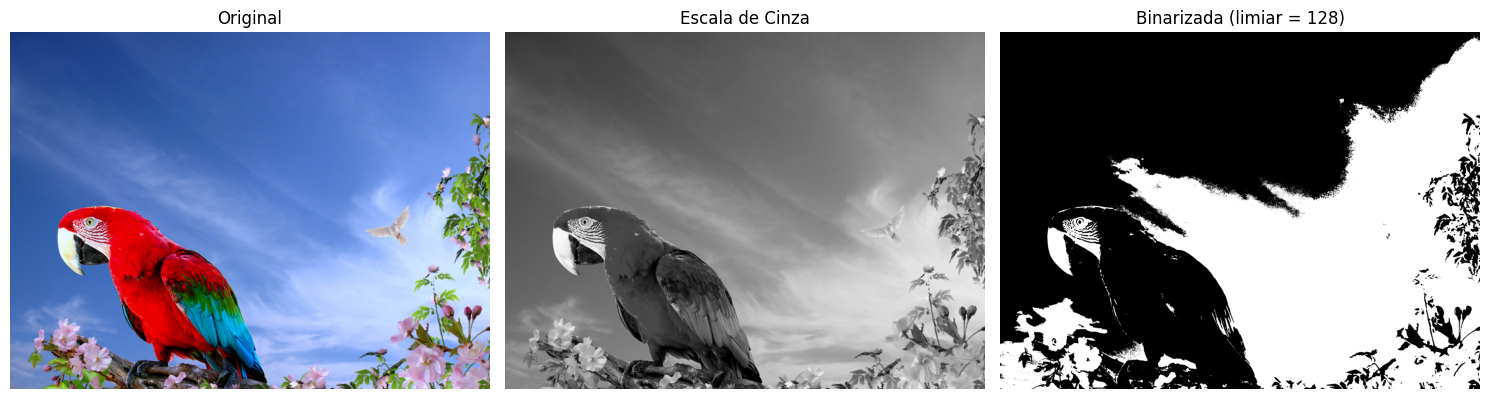

In [47]:
# Etapa 7: Exibir as três imagens: original, cinza, binária
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

# Escala de cinza
plt.subplot(1, 3, 2)
plt.title("Escala de Cinza")
plt.imshow(cinza, cmap='gray')
plt.axis("off")

# Binária
plt.subplot(1, 3, 3)
plt.title(f"Binarizada (limiar = {limiar})")
plt.imshow(binaria, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()